# Estudo de Taxas de Mutação e Decay (Fase 2)

Após provarmos na Fase 1 que a estratégia Híbrida é estruturalmente a melhor
(RMSE 24.88 ± 0.27 em pop 200, contra 25.30 do Híbrido+Depth e 28.06 do Vertex Only),
vamos afinar os seus parâmetros principais: a **Taxa de Mutação** e o **Decay**.

Fixamos o **tamanho da população em 200**, pois a Fase 1 mostrou que esta foi a
melhor população para todos os métodos, de forma monótona e estatisticamente
significativa (Híbrido: 29.03 → 26.81 → 24.88 para pop 50/100/200; teste de
tamanho de população p < 0.01). Afinamos a taxa de mutação no mesmo regime em
que o GA final irá operar.

O objetivo deste caderno é responder à pergunta:
*De qual agressividade de mutação o algoritmo necessita, e será que decrescer essa taxa ao longo do tempo (Decay) acelera a convergência?*

**Estratégias a testar (Todas com Mutação Híbrida):**
- **Constant (0.01)**: Taxa muito baixa e fixa.
- **Constant (0.05)**: Taxa média e fixa.
- **Constant (0.10)**: Taxa agressiva e fixa.
- **Decay (0.05 -> 0.01)**: Começa moderada e acalma nas últimas gerações para fine-tuning.
- **Decay (0.10 -> 0.01)**: Começa muito agressiva para máxima exploração inicial e acalma no fim.


In [1]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import os
import time
import warnings
from copy import deepcopy

warnings.filterwarnings('ignore')

WIDTH = 300
HEIGHT = 400
NUM_TRIANGLES = 100

## 1. Funções Base e Operadores Fixos


In [2]:
def load_target_image(filepath):
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Imagem {filepath} não encontrada!")
    img = cv2.imread(filepath)
    img = cv2.resize(img, (WIDTH, HEIGHT))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def create_random_triangle(target_img=None):
    cx, cy = random.randint(0, WIDTH - 1), random.randint(0, HEIGHT - 1)
    size = random.randint(10, 150)
    if target_img is not None:
        r, g, b = target_img[cy, cx]
        color = (int(r), int(g), int(b))
    else:
        color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
    return {
        'p1': (np.clip(cx + random.randint(-size, size), 0, WIDTH), np.clip(cy + random.randint(-size, size), 0, HEIGHT)),
        'p2': (np.clip(cx + random.randint(-size, size), 0, WIDTH), np.clip(cy + random.randint(-size, size), 0, HEIGHT)),
        'p3': (np.clip(cx + random.randint(-size, size), 0, WIDTH), np.clip(cy + random.randint(-size, size), 0, HEIGHT)),
        'color': color,
        'alpha': random.uniform(0.05, 0.4),
        'z': random.random()
    }

def create_random_individual(target_img=None):
    return [create_random_triangle(target_img) for _ in range(NUM_TRIANGLES)]

def render_individual(individual):
    canvas = np.zeros((HEIGHT, WIDTH, 3), dtype=np.uint8)
    ordered_individual = sorted(individual, key=lambda tri: tri.get('z', 0))
    for tri in ordered_individual:
        pts = np.array([tri['p1'], tri['p2'], tri['p3']], np.int32).reshape((-1, 1, 2))
        overlay = canvas.copy()
        cv2.fillPoly(overlay, [pts], tri['color'])
        cv2.addWeighted(overlay, tri['alpha'], canvas, 1 - tri['alpha'], 0, canvas)
    return canvas

def calculate_fitness(rendered, target):
    diff = rendered.astype(np.float32) - target.astype(np.float32)
    return np.sqrt(np.mean(np.square(diff)))

def tournament_selection(population, fitnesses, tournament_size=7):
    indices = random.sample(range(len(population)), min(tournament_size, len(population)))
    best_idx = min(indices, key=lambda i: fitnesses[i])
    return deepcopy(population[best_idx])

def crossover(p1, p2):
    split = random.randint(0, NUM_TRIANGLES)
    return p1[:split] + p2[split:]



### 1.1 Medidas de Diversidade da População

Quatro medidas, cruzando **o que** medimos com **a ferramenta estatística**:

|              | **Variância**         | **Entropia (Shannon)**  |
|--------------|-----------------------|-------------------------|
| **Genótipo** | `genotypic_variance`  | `genotypic_entropy`     |
| **Fenótipo** | `phenotypic_variance` | `phenotypic_entropy`    |

**Genótipo** = nível da representação (11 genes/triângulo × 100 = vetor de 1100 valores). Como os genes vivem em escalas diferentes (coordenadas 0–300/0–400, cor 0–255, `alpha`/`z` em 0–1), **normalizamos cada gene para [0,1]** antes de medir, senão a variância das coordenadas dominaria tudo. **Fenótipo** = usamos o fitness (RMSE) como descritor escalar.

Binning da entropia: **genótipo** usa intervalo fixo [0,1] (genes já normalizados a um intervalo teórico), logo a entropia genotípica **colapsa** quando os alelos convergem. **Fenótipo** usa o intervalo [min,max] da geração (o RMSE não tem escala fixa ao longo da corrida): mede a *forma/uniformidade* da distribuição, enquanto a **variância fenotípica** captura a *magnitude* do espalhamento.

Neste estudo (taxas de mutação), estas curvas são especialmente úteis: esperamos que `rate_0.00` colapse a diversidade quase de imediato (sem mutação, só recombina o material inicial) e que taxas mais altas / sem decay mantenham diversidade mais elevada por mais tempo.

In [3]:
# =============================================================================
# MEDIDAS DE DIVERSIDADE — grelha 2x2 (genótipo/fenótipo × variância/entropia)
# =============================================================================
def individual_to_vector(individual):
    """Achata um indivíduo num vetor de genes normalizados em [0,1] (11*NUM_TRIANGLES)."""
    genes = []
    for tri in individual:
        (x1, y1), (x2, y2), (x3, y3) = tri['p1'], tri['p2'], tri['p3']
        r, g, b = tri['color']
        genes.extend([
            x1 / WIDTH,  x2 / WIDTH,  x3 / WIDTH,
            y1 / HEIGHT, y2 / HEIGHT, y3 / HEIGHT,
            r / 255.0,   g / 255.0,   b / 255.0,
            float(np.clip(tri.get('alpha', 0.0), 0.0, 1.0)),
            float(np.clip(tri.get('z', 0.0), 0.0, 1.0)),
        ])
    return np.asarray(genes, dtype=np.float32)

def population_matrix(population):
    return np.vstack([individual_to_vector(ind) for ind in population])

def _shannon_entropy(values, bins=20, value_range=(0.0, 1.0)):
    counts, _ = np.histogram(values, bins=bins, range=value_range)
    total = counts.sum()
    if total == 0:
        return 0.0
    p = counts / total
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

def genotypic_variance(population):
    M = population_matrix(population)
    return float(np.mean(np.var(M, axis=0)))

def genotypic_entropy(population, bins=20):
    M = population_matrix(population)
    ent = [_shannon_entropy(M[:, j], bins=bins, value_range=(0.0, 1.0)) for j in range(M.shape[1])]
    return float(np.mean(ent))

def phenotypic_variance(fitnesses):
    return float(np.var(np.asarray(fitnesses, dtype=np.float64)))

def phenotypic_entropy(fitnesses, bins=20):
    f = np.asarray(fitnesses, dtype=np.float64)
    lo, hi = float(f.min()), float(f.max())
    if hi <= lo:
        return 0.0
    return _shannon_entropy(f, bins=bins, value_range=(lo, hi))

print("Diversity measures defined: genotypic/phenotypic x variance/entropy.")


Diversity measures defined: genotypic/phenotypic x variance/entropy.


## 2. Mutação Vencedora (Híbrida)
Utilizamos exclusivamente a mutação híbrida que atua nos vértices, cores e estrutura.


In [4]:
def mutate_hybrid(individual, target_img=None, mutation_rate=0.04):
    new_ind = []
    for tri in individual:
        new_tri = tri.copy()
        
        # Vertex
        step_pos = 5 if random.random() < 0.8 else 30
        for p_key in ['p1', 'p2', 'p3']:
            if random.random() < mutation_rate:
                new_tri[p_key] = (np.clip(new_tri[p_key][0] + random.randint(-step_pos, step_pos), 0, WIDTH),
                                  np.clip(new_tri[p_key][1] + random.randint(-step_pos, step_pos), 0, HEIGHT))
                                  
        # Color
        step_col = 10 if random.random() < 0.8 else 60
        if random.random() < mutation_rate:
            r = np.clip(new_tri['color'][0] + random.randint(-step_col, step_col), 0, 255)
            g = np.clip(new_tri['color'][1] + random.randint(-step_col, step_col), 0, 255)
            b = np.clip(new_tri['color'][2] + random.randint(-step_col, step_col), 0, 255)
            new_tri['color'] = (int(r), int(g), int(b))
        if random.random() < (mutation_rate * 0.5):
            new_tri['alpha'] = np.clip(new_tri['alpha'] + random.uniform(-0.1, 0.1), 0.05, 0.6)
            
        # Structural
        if random.random() < (mutation_rate * 0.4):
            cx = (new_tri['p1'][0] + new_tri['p2'][0] + new_tri['p3'][0]) / 3
            cy = (new_tri['p1'][1] + new_tri['p2'][1] + new_tri['p3'][1]) / 3
            new_tri['p1'] = (int(cx + (new_tri['p1'][0] - cx)*0.8), int(cy + (new_tri['p1'][1] - cy)*0.8))
            new_tri['p2'] = (int(cx + (new_tri['p2'][0] - cx)*0.8), int(cy + (new_tri['p2'][1] - cy)*0.8))
            new_tri['p3'] = (int(cx + (new_tri['p3'][0] - cx)*0.8), int(cy + (new_tri['p3'][1] - cy)*0.8))
        if random.random() < (mutation_rate * 0.05):
            new_tri = create_random_triangle(target_img)
            
        new_ind.append(new_tri)
    return new_ind



## 3. Motor do GA (com suporte a Mutation Decay)


In [5]:
def evolve_with_mutation(target_img, mutation_fn, mutation_params=None,
                         pop_size=200, generations=10000, mutation_rate=0.05,
                         elite_fraction=0.1, seed=42, log_interval=50):
    random.seed(seed)
    np.random.seed(seed)
    if mutation_params is None: mutation_params = {}

    use_decay = mutation_params.get('use_decay', False)
    min_rate = mutation_params.get('min_rate', 0.01)

    population = [create_random_individual(target_img) for _ in range(pop_size)]
    elite_size = max(1, int(pop_size * elite_fraction))

    metrics = {'generation': [], 'best_fitness': [], 'avg_fitness': [], 'std_fitness': [], 'time_elapsed': [],
               'geno_var': [], 'geno_entropy': [], 'pheno_var': [], 'pheno_entropy': []}
    start_time = time.time()

    for gen in range(generations):
        fitnesses = [calculate_fitness(render_individual(ind), target_img) for ind in population]
        sorted_indices = np.argsort(fitnesses)
        population = [population[i] for i in sorted_indices]
        fitnesses = [fitnesses[i] for i in sorted_indices]

        if gen % log_interval == 0 or gen == generations - 1:
            elapsed = time.time() - start_time
            metrics['generation'].append(gen)
            metrics['best_fitness'].append(fitnesses[0])
            metrics['avg_fitness'].append(np.mean(fitnesses))
            metrics['std_fitness'].append(np.std(fitnesses))
            metrics['time_elapsed'].append(elapsed)
            # --- diversidade da população (grelha 2x2) ---
            metrics['geno_var'].append(genotypic_variance(population))
            metrics['geno_entropy'].append(genotypic_entropy(population))
            metrics['pheno_var'].append(phenotypic_variance(fitnesses))
            metrics['pheno_entropy'].append(phenotypic_entropy(fitnesses))
            if gen % (log_interval * 10) == 0 or gen == generations - 1:
                print(f"    Gen {gen:05d} | Best: {fitnesses[0]:.2f} | Time: {elapsed:.1f}s")

        new_population = [deepcopy(population[i]) for i in range(elite_size)]
        
        current_mutation_rate = mutation_rate
        if use_decay:
            current_mutation_rate = max(min_rate, mutation_rate * (1 - gen / generations))

        num_children = pop_size - elite_size
        k = max(2, int(0.1 * pop_size))
        for _ in range(num_children):
            p1 = tournament_selection(population, fitnesses, tournament_size=k)
            p2 = tournament_selection(population, fitnesses, tournament_size=k)
            child = crossover(p1, p2)
            child = mutation_fn(child, target_img, mutation_rate=current_mutation_rate)
            new_population.append(child)

        population = new_population

    best_rendered = render_individual(population[0])
    return population[0], metrics, best_rendered



## 4. Configuração Experimental (Taxas e Decay)


In [6]:
SEEDS = [42, 123, 456, 789, 1024]
GENERATIONS = 1000  # Aumentar para 10000 para resultados definitivos
ELITE_FRACTION = 0.1
LOG_INTERVAL = 50

# Apenas 1 tamanho de população, focado na mutação
POPULATION_SIZES = [200]  # melhor população identificada na Fase 1 (RMSE mínimo, p<0.01 vs 100)

MUTATION_CONFIGS = {
    'rate_0.00':  {'fn': mutate_hybrid, 'params': {'use_decay': False}, 'rate': 0.00, 'label': 'Constant (0.00)', 'color': '#757575'},
    'rate_0.01':  {'fn': mutate_hybrid, 'params': {'use_decay': False}, 'rate': 0.01, 'label': 'Constant (0.01)', 'color': '#1565C0'},
    'rate_0.05':  {'fn': mutate_hybrid, 'params': {'use_decay': False}, 'rate': 0.05, 'label': 'Constant (0.05)', 'color': '#E91E63'},
    'rate_0.10':  {'fn': mutate_hybrid, 'params': {'use_decay': False}, 'rate': 0.10, 'label': 'Constant (0.10)', 'color': '#9C27B0'},
    'decay_0.05': {'fn': mutate_hybrid, 'params': {'use_decay': True, 'min_rate': 0.01}, 'rate': 0.05, 'label': 'Decay (0.05 -> 0.01)', 'color': '#FF9800'},
    'decay_0.10': {'fn': mutate_hybrid, 'params': {'use_decay': True, 'min_rate': 0.01}, 'rate': 0.10, 'label': 'Decay (0.10 -> 0.01)', 'color': '#4CAF50'}
}

target = load_target_image("girl_pearl_earing.png")
total_exps = len(MUTATION_CONFIGS) * len(POPULATION_SIZES) * len(SEEDS)
print(f"Total de experiências: {total_exps}")



Total de experiências: 30


## 5. Execução das Experiências


In [7]:
results = {}
exp_num = 0
for pop_size in POPULATION_SIZES:
    for config_name, config in MUTATION_CONFIGS.items():
        for seed in SEEDS:
            exp_num += 1
            key = (config_name, pop_size, seed)
            print(f"\n{'=' * 65}\n  Exp {exp_num}/{total_exps}: {config['label']} | Pop: {pop_size} | Seed: {seed}\n{'=' * 65}")
            best_ind, metrics, best_rendered = evolve_with_mutation(
                target_img=target,
                mutation_fn=config['fn'],
                mutation_params=config['params'],
                pop_size=pop_size,
                generations=GENERATIONS,
                mutation_rate=config['rate'],  # <-- Usa a taxa definida no dicionário
                elite_fraction=ELITE_FRACTION,
                seed=seed,
                log_interval=LOG_INTERVAL
            )
            results[key] = {
                'metrics': metrics,
                'rendered': best_rendered,
                'label': config['label'],
                'color': config['color'],
                'final_rmse': metrics['best_fitness'][-1],
                'total_time': metrics['time_elapsed'][-1]
            }
            print(f"  → Final RMSE: {results[key]['final_rmse']:.2f}")




  Exp 1/30: Constant (0.00) | Pop: 200 | Seed: 42
    Gen 00000 | Best: 72.65 | Time: 2.2s
    Gen 00500 | Best: 55.46 | Time: 1393.6s
    Gen 00999 | Best: 55.46 | Time: 2833.4s
  → Final RMSE: 55.46

  Exp 2/30: Constant (0.00) | Pop: 200 | Seed: 123
    Gen 00000 | Best: 75.04 | Time: 2.5s
    Gen 00500 | Best: 59.10 | Time: 1467.6s
    Gen 00999 | Best: 59.10 | Time: 2921.8s
  → Final RMSE: 59.10

  Exp 3/30: Constant (0.00) | Pop: 200 | Seed: 456
    Gen 00000 | Best: 70.02 | Time: 2.0s
    Gen 00500 | Best: 50.98 | Time: 1453.5s
    Gen 00999 | Best: 50.98 | Time: 2893.6s
  → Final RMSE: 50.98

  Exp 4/30: Constant (0.00) | Pop: 200 | Seed: 789
    Gen 00000 | Best: 72.37 | Time: 2.3s
    Gen 00500 | Best: 57.37 | Time: 1473.5s
    Gen 00999 | Best: 57.37 | Time: 2936.4s
  → Final RMSE: 57.37

  Exp 5/30: Constant (0.00) | Pop: 200 | Seed: 1024
    Gen 00000 | Best: 72.07 | Time: 2.6s
    Gen 00500 | Best: 52.76 | Time: 1481.4s
    Gen 00999 | Best: 52.76 | Time: 2939.6s
  → Fin

## 7. Análise e Visualização dos Resultados

### 7.1 Tabela Resumo
Comparação numérica de todos os métodos e tamanhos de população (média ± std de 5 seeds).


In [8]:
# =============================================================================
# TABELA RESUMO (média ± std de 5 seeds)
# =============================================================================
print(f"{'Método':<25} {'Pop':>5} {'RMSE (média±std)':>20} {'Tempo (média)':>14}")
print("=" * 70)

for pop_size in POPULATION_SIZES:
    for config_name, config in MUTATION_CONFIGS.items():
        rmses = [results[(config_name, pop_size, s)]['final_rmse'] for s in SEEDS]
        times = [results[(config_name, pop_size, s)]['total_time'] for s in SEEDS]
        print(f"{config['label']:<25} {pop_size:>5} "
              f"{np.mean(rmses):>8.2f} ± {np.std(rmses):<8.2f} "
              f"{np.mean(times):>10.1f}s")
    print("-" * 70)


Método                      Pop     RMSE (média±std)  Tempo (média)
Constant (0.00)             200    55.13 ± 2.96         2905.0s
Constant (0.01)             200    20.72 ± 0.35         3013.4s
Constant (0.05)             200    25.31 ± 0.32         3338.2s
Constant (0.10)             200    27.92 ± 0.20         3112.6s
Decay (0.05 -> 0.01)        200    21.64 ± 0.43         3072.1s
Decay (0.10 -> 0.01)        200    22.60 ± 0.61         3462.3s
----------------------------------------------------------------------


### 7.2 Curvas de Convergência (Média ± Std)
Evolução do melhor RMSE ao longo das gerações para cada método de seleção.


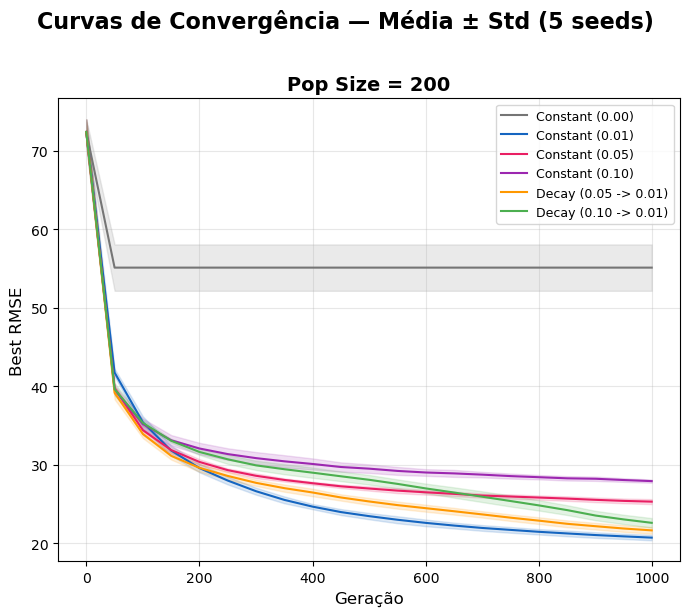

Gráfico guardado: convergence_mutation_rates.png


In [9]:
# =============================================================================
# CURVAS DE CONVERGÊNCIA — Média ± Std de 5 seeds
# =============================================================================
fig, axes = plt.subplots(1, len(POPULATION_SIZES), figsize=(7 * len(POPULATION_SIZES), 6),
                         sharey=True)
if len(POPULATION_SIZES) == 1:
    axes = [axes]

for ax_idx, pop_size in enumerate(POPULATION_SIZES):
    ax = axes[ax_idx]
    for config_name, config in MUTATION_CONFIGS.items():
        # Recolher curvas de todas as seeds
        all_curves = []
        for seed in SEEDS:
            m = results[(config_name, pop_size, seed)]['metrics']
            all_curves.append(m['best_fitness'])

        generations = results[(config_name, pop_size, SEEDS[0])]['metrics']['generation']
        mean_curve = np.mean(all_curves, axis=0)
        std_curve = np.std(all_curves, axis=0)

        ax.plot(generations, mean_curve,
                label=config['label'], color=config['color'], linewidth=1.5)
        ax.fill_between(generations, mean_curve - std_curve, mean_curve + std_curve,
                        color=config['color'], alpha=0.15)

    ax.set_title(f"Pop Size = {pop_size}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Geração", fontsize=12)
    if ax_idx == 0:
        ax.set_ylabel("Best RMSE", fontsize=12)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("Curvas de Convergência — Média ± Std (5 seeds)",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("convergence_mutation_rates.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado: convergence_mutation_rates.png")


### 7.3 Evolução da Diversidade Genética (Média ± Std)
O desvio-padrão do fitness na população indica a diversidade genética.
Métodos com alta pressão seletiva tendem a reduzir a diversidade mais rapidamente.


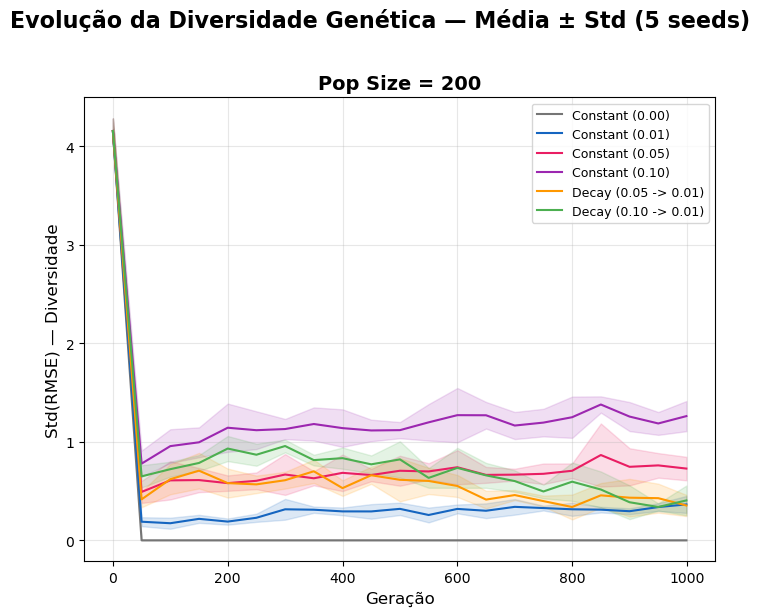

Gráfico guardado: diversity_mutation_rates.png


In [10]:
# =============================================================================
# DIVERSIDADE GENÉTICA — Média ± Std de 5 seeds
# =============================================================================
fig, axes = plt.subplots(1, len(POPULATION_SIZES), figsize=(7 * len(POPULATION_SIZES), 6),
                         sharey=True)
if len(POPULATION_SIZES) == 1:
    axes = [axes]

for ax_idx, pop_size in enumerate(POPULATION_SIZES):
    ax = axes[ax_idx]
    for config_name, config in MUTATION_CONFIGS.items():
        all_curves = []
        for seed in SEEDS:
            m = results[(config_name, pop_size, seed)]['metrics']
            all_curves.append(m['std_fitness'])

        generations = results[(config_name, pop_size, SEEDS[0])]['metrics']['generation']
        mean_curve = np.mean(all_curves, axis=0)
        std_curve = np.std(all_curves, axis=0)

        ax.plot(generations, mean_curve,
                label=config['label'], color=config['color'], linewidth=1.5)
        ax.fill_between(generations, mean_curve - std_curve, mean_curve + std_curve,
                        color=config['color'], alpha=0.15)

    ax.set_title(f"Pop Size = {pop_size}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Geração", fontsize=12)
    if ax_idx == 0:
        ax.set_ylabel("Std(RMSE) — Diversidade", fontsize=12)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("Evolução da Diversidade Genética — Média ± Std (5 seeds)",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("diversity_mutation_rates.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado: diversity_mutation_rates.png")


### 7.3.1 Diversidade da População — Grelha 2×2 (Genótipo/Fenótipo × Variância/Entropia)

As quatro medidas (secção 1.1) ao longo das gerações, média ± std sobre as 5 seeds. Painel superior = **genótipo** (variância | entropia), inferior = **fenótipo** (variância | entropia). Curvas decrescentes indicam perda de diversidade.

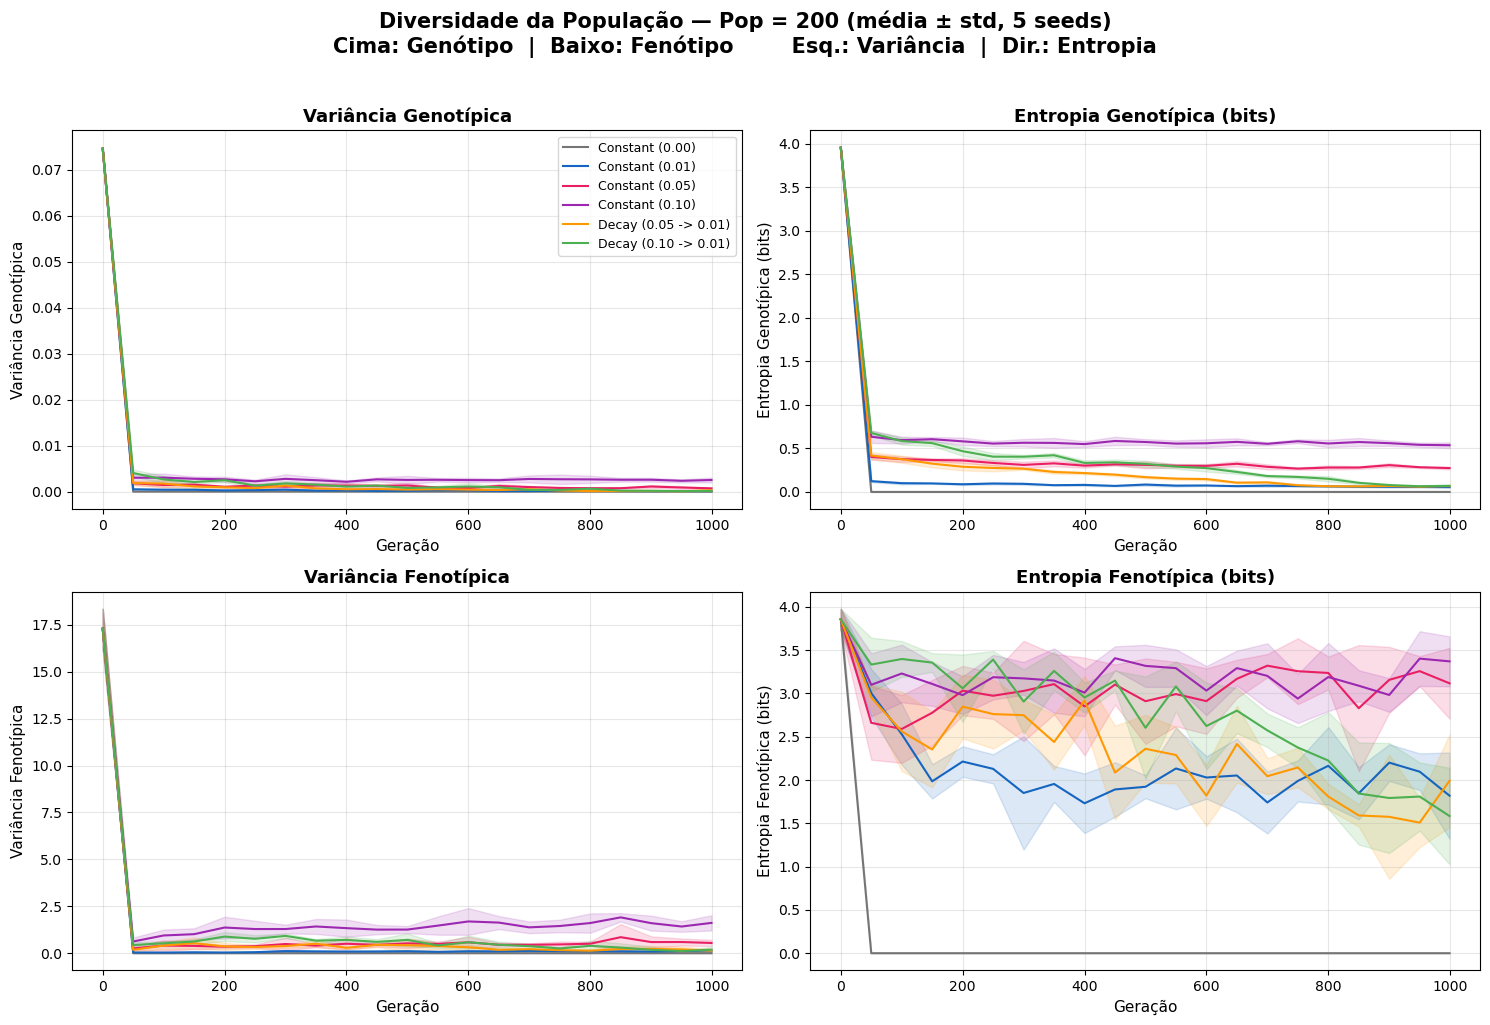

Gráfico guardado: diversity_grid_pop200.png


In [11]:
# =============================================================================
# DIVERSIDADE — grelha 2x2 (genótipo/fenótipo x variância/entropia)
# =============================================================================
_probe = results[(list(MUTATION_CONFIGS)[0], POPULATION_SIZES[0], SEEDS[0])]['metrics']
if 'geno_var' not in _probe:
    print("As métricas de diversidade ainda não existem nos resultados.\n"
          "Volta a correr a célula do motor do GA (secção 3) e depois a secção 5 (Execução).")
else:
    DIV_PANELS = [
        ('geno_var',      'Variância Genotípica'),
        ('geno_entropy',  'Entropia Genotípica (bits)'),
        ('pheno_var',     'Variância Fenotípica'),
        ('pheno_entropy', 'Entropia Fenotípica (bits)'),
    ]
    for pop_size in POPULATION_SIZES:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.ravel()
        gens = results[(list(MUTATION_CONFIGS)[0], pop_size, SEEDS[0])]['metrics']['generation']
        for ax, (mkey, ylabel) in zip(axes, DIV_PANELS):
            for config_name, config in MUTATION_CONFIGS.items():
                curves = [results[(config_name, pop_size, s)]['metrics'][mkey] for s in SEEDS]
                mean_c = np.mean(curves, axis=0); std_c = np.std(curves, axis=0)
                ax.plot(gens, mean_c, label=config['label'], color=config['color'], linewidth=1.5)
                ax.fill_between(gens, mean_c - std_c, mean_c + std_c, color=config['color'], alpha=0.15)
            ax.set_title(ylabel, fontsize=13, fontweight='bold')
            ax.set_xlabel("Geração", fontsize=11); ax.set_ylabel(ylabel, fontsize=11)
            ax.grid(True, alpha=0.3)
        axes[0].legend(fontsize=9, loc='upper right')
        fig.suptitle(f"Diversidade da População — Pop = {pop_size} (média ± std, 5 seeds)\n"
                     f"Cima: Genótipo  |  Baixo: Fenótipo        Esq.: Variância  |  Dir.: Entropia",
                     fontsize=15, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(f"diversity_grid_pop{pop_size}.png", dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Gráfico guardado: diversity_grid_pop{pop_size}.png")


### 7.4 Comparação de RMSE Final — Barplots com Barras de Erro
Comparação do RMSE final atingido por cada método, agrupado por tamanho de população.


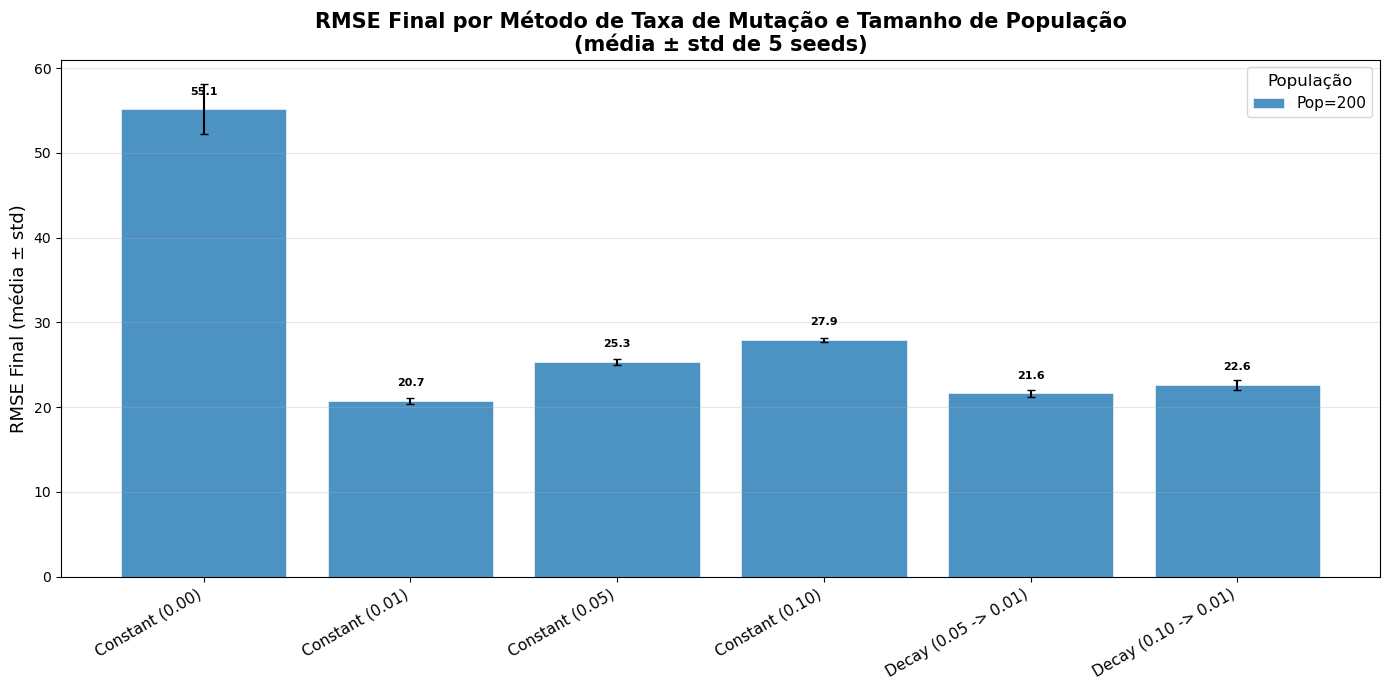

Gráfico guardado: barplot_mutation_rates.png


In [12]:
# =============================================================================
# BARPLOT — RMSE Final por método e pop size (média ± std de 5 seeds)
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 7))

n_methods = len(MUTATION_CONFIGS)
n_pops = len(POPULATION_SIZES)
bar_width = 0.8 / n_pops
x = np.arange(n_methods)

for pop_idx, pop_size in enumerate(POPULATION_SIZES):
    rmse_means = []
    rmse_stds = []
    labels_list = []
    for config_name, config in MUTATION_CONFIGS.items():
        rmses = [results[(config_name, pop_size, s)]['final_rmse'] for s in SEEDS]
        rmse_means.append(np.mean(rmses))
        rmse_stds.append(np.std(rmses))
        labels_list.append(config['label'])

    offset = (pop_idx - n_pops / 2 + 0.5) * bar_width
    bars = ax.bar(x + offset, rmse_means, bar_width, yerr=rmse_stds,
                  label=f"Pop={pop_size}", alpha=0.8, edgecolor='white',
                  linewidth=0.5, capsize=3)

    for bar, val in zip(bars, rmse_means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
                f"{val:.1f}", ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels_list, rotation=30, ha='right', fontsize=11)
ax.set_ylabel("RMSE Final (média ± std)", fontsize=13)
ax.set_title("RMSE Final por Método de Taxa de Mutação e Tamanho de População\n(média ± std de 5 seeds)",
             fontsize=15, fontweight='bold')
ax.legend(fontsize=11, title="População", title_fontsize=12)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("barplot_mutation_rates.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado: barplot_mutation_rates.png")


### 7.5 Evolução do Fitness Médio da População (Média ± Std)
Complementa a análise de convergência: mostra como o fitness médio de toda a população 
evolui (não apenas o melhor indivíduo).


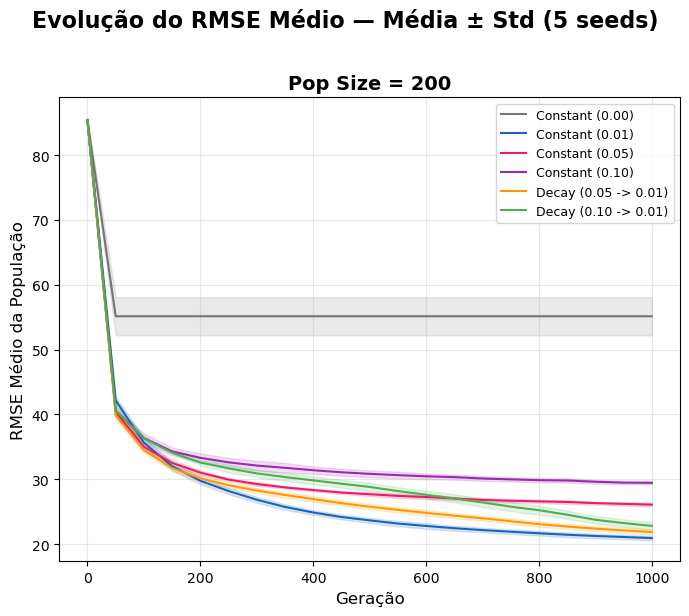

Gráfico guardado: avg_fitness_mutation_rates.png


In [13]:
# =============================================================================
# CURVAS DE FITNESS MÉDIO — Média ± Std de 5 seeds
# =============================================================================
fig, axes = plt.subplots(1, len(POPULATION_SIZES), figsize=(7 * len(POPULATION_SIZES), 6),
                         sharey=True)
if len(POPULATION_SIZES) == 1:
    axes = [axes]

for ax_idx, pop_size in enumerate(POPULATION_SIZES):
    ax = axes[ax_idx]
    for config_name, config in MUTATION_CONFIGS.items():
        all_curves = []
        for seed in SEEDS:
            m = results[(config_name, pop_size, seed)]['metrics']
            all_curves.append(m['avg_fitness'])

        generations = results[(config_name, pop_size, SEEDS[0])]['metrics']['generation']
        mean_curve = np.mean(all_curves, axis=0)
        std_curve = np.std(all_curves, axis=0)

        ax.plot(generations, mean_curve,
                label=config['label'], color=config['color'], linewidth=1.5)
        ax.fill_between(generations, mean_curve - std_curve, mean_curve + std_curve,
                        color=config['color'], alpha=0.15)

    ax.set_title(f"Pop Size = {pop_size}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Geração", fontsize=12)
    if ax_idx == 0:
        ax.set_ylabel("RMSE Médio da População", fontsize=12)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("Evolução do RMSE Médio — Média ± Std (5 seeds)",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("avg_fitness_mutation_rates.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado: avg_fitness_mutation_rates.png")


### 7.6 Tempo de Execução (Média ± Std)
Comparação do tempo computacional de cada método.


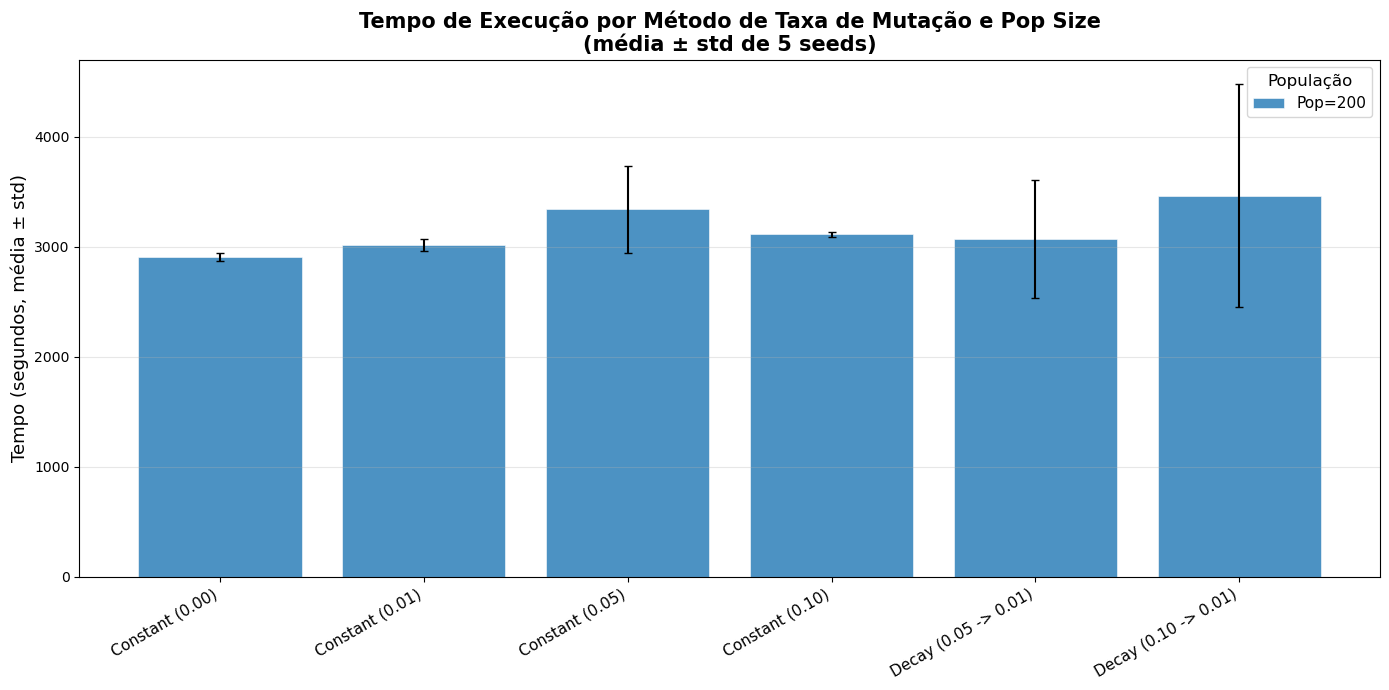

Gráfico guardado: time_mutation_rates.png


In [14]:
# =============================================================================
# TEMPO DE EXECUÇÃO — Média ± Std de 5 seeds
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 7))

n_methods = len(MUTATION_CONFIGS)
n_pops = len(POPULATION_SIZES)
bar_width = 0.8 / n_pops
x = np.arange(n_methods)

for pop_idx, pop_size in enumerate(POPULATION_SIZES):
    time_means = []
    time_stds = []
    labels_list = []
    for config_name, config in MUTATION_CONFIGS.items():
        times = [results[(config_name, pop_size, s)]['total_time'] for s in SEEDS]
        time_means.append(np.mean(times))
        time_stds.append(np.std(times))
        labels_list.append(config['label'])

    offset = (pop_idx - n_pops / 2 + 0.5) * bar_width
    ax.bar(x + offset, time_means, bar_width, yerr=time_stds,
           label=f"Pop={pop_size}", alpha=0.8, edgecolor='white',
           linewidth=0.5, capsize=3)

ax.set_xticks(x)
ax.set_xticklabels(labels_list, rotation=30, ha='right', fontsize=11)
ax.set_ylabel("Tempo (segundos, média ± std)", fontsize=13)
ax.set_title("Tempo de Execução por Método de Taxa de Mutação e Pop Size\n(média ± std de 5 seeds)",
             fontsize=15, fontweight='bold')
ax.legend(fontsize=11, title="População", title_fontsize=12)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("time_mutation_rates.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado: time_mutation_rates.png")


### 7.7 Melhores Imagens Geradas
Visualização lado a lado das imagens geradas por cada método de seleção.


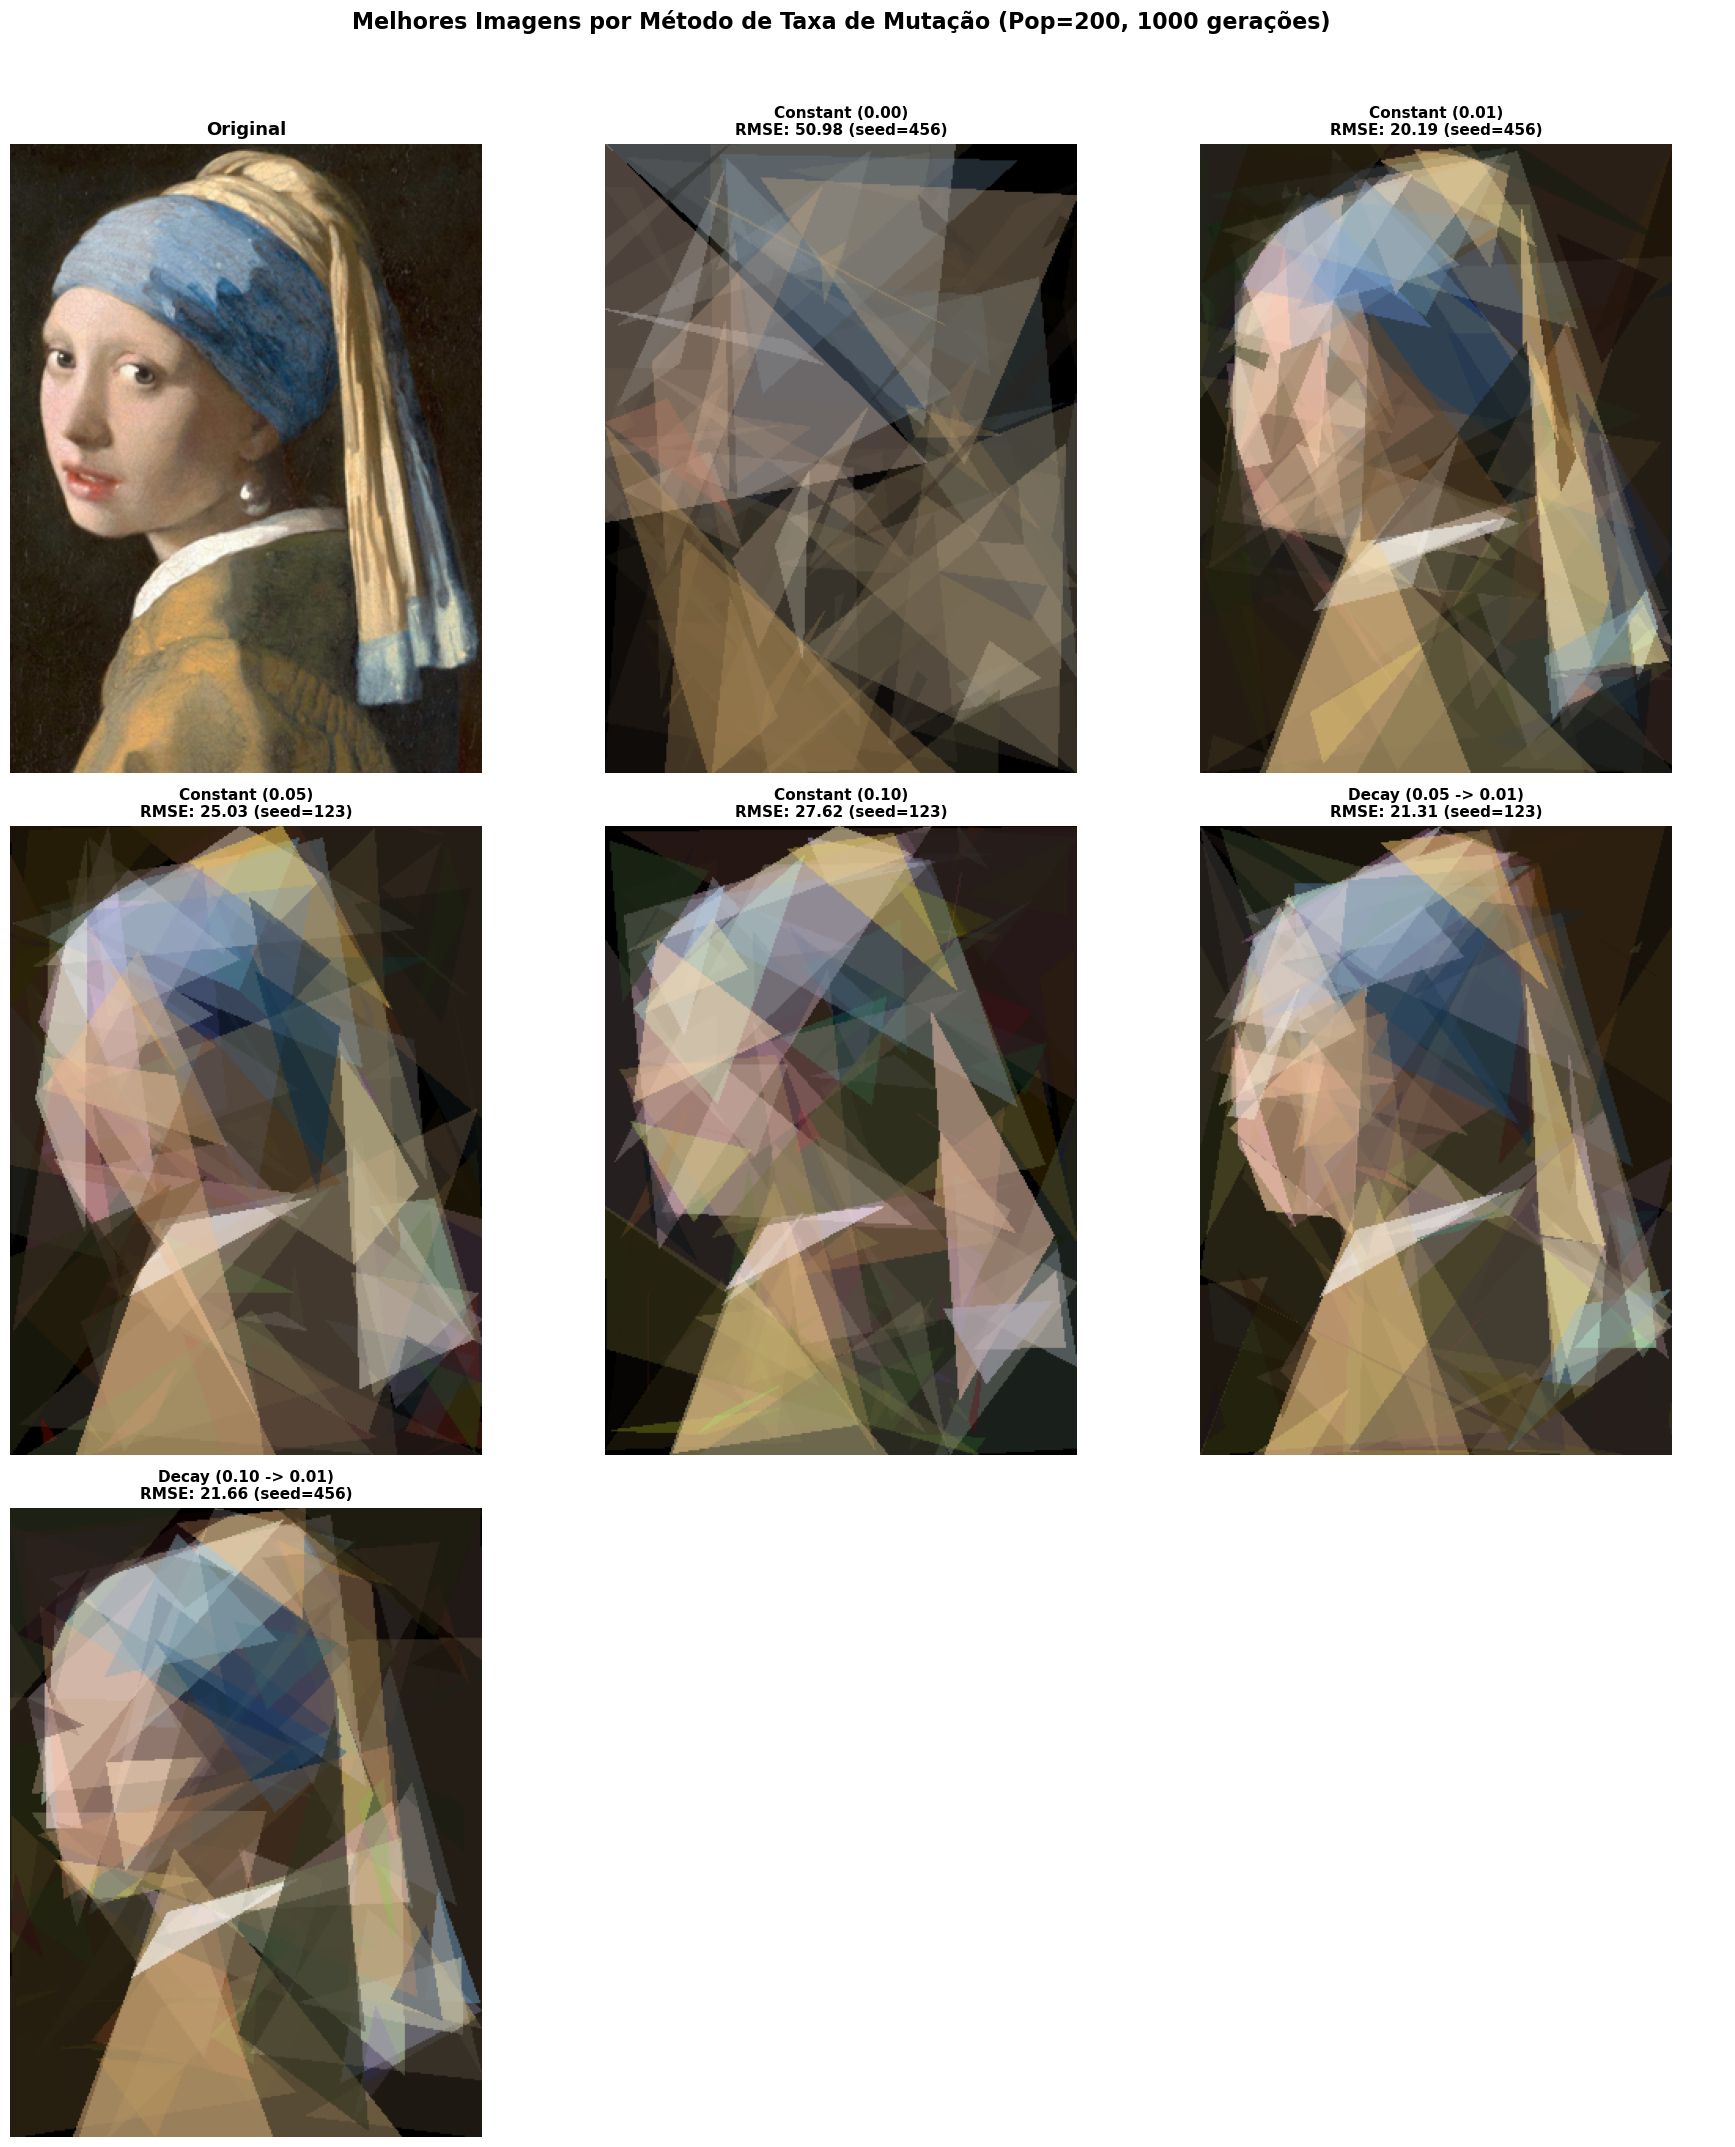

Gráfico guardado: images_mutation_rates.png


In [15]:
# =============================================================================
# GRID DE IMAGENS — Melhor resultado de cada método (Pop=200, melhor seed)
# =============================================================================
display_pop = 200
n_methods = len(MUTATION_CONFIGS)
n_cols = 3
n_rows = (n_methods + 1 + n_cols - 1) // n_cols  # +1 para o original

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 7 * n_rows))
axes = axes.flatten()

# Mostrar original
axes[0].imshow(target)
axes[0].set_title("Original", fontsize=13, fontweight='bold')
axes[0].axis('off')

# Mostrar melhor resultado (melhor seed) de cada método
for idx, (config_name, config) in enumerate(MUTATION_CONFIGS.items()):
    # Encontrar a seed com menor RMSE
    best_seed = min(SEEDS, key=lambda s: results[(config_name, display_pop, s)]['final_rmse'])
    best_key = (config_name, display_pop, best_seed)

    ax = axes[idx + 1]
    ax.imshow(results[best_key]['rendered'])
    rmse = results[best_key]['final_rmse']
    ax.set_title(f"{config['label']}\nRMSE: {rmse:.2f} (seed={best_seed})",
                 fontsize=11, fontweight='bold')
    ax.axis('off')

# Esconder eixos vazios
for idx in range(n_methods + 1, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f"Melhores Imagens por Método de Taxa de Mutação (Pop={display_pop}, {GENERATIONS} gerações)",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("images_mutation_rates.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado: images_mutation_rates.png")


## 8. Validação Estatística (Testes de Hipóteses)

As visualizações da secção anterior dão-nos uma intuição visual sobre o desempenho
dos métodos. Agora, usamos **testes de hipóteses** para comprovar se as diferenças
observadas são **estatisticamente significativas** ou se poderiam ser resultado do acaso.

**Testes utilizados:**
- **Kruskal-Wallis H-test** (ANOVA não-paramétrica): Testa se existe pelo menos uma diferença significativa entre todos os métodos
- **Mann-Whitney U test** (pairwise): Testa quais pares específicos de métodos são significativamente diferentes
- **Correção de Bonferroni**: Ajusta os p-values para comparações múltiplas (evitar falsos positivos)

### 8.1 Teste por Método de Taxa de Mutação (Pop Size fixo)
Analisamos as distribuições de RMSE por **método**, fixando cada tamanho de população separadamente.


In [16]:
# =============================================================================
# ORGANIZAR DADOS PARA ANÁLISE ESTATÍSTICA
# =============================================================================
from scipy import stats
from itertools import combinations

method_names = list(MUTATION_CONFIGS.keys())
method_labels_map = {k: v['label'] for k, v in MUTATION_CONFIGS.items()}

# Organizar RMSE final por (método, pop_size): lista de 5 valores
method_rmses = {}  # {(method, pop_size): [rmse_s1, rmse_s2, ...]}
for config_name in MUTATION_CONFIGS:
    for pop_size in POPULATION_SIZES:
        method_rmses[(config_name, pop_size)] = [
            results[(config_name, pop_size, s)]['final_rmse'] for s in SEEDS
        ]

print("Dados organizados para análise estatística.")
print(f"Configurações: {len(method_rmses)} combinações (método × pop_size)")
print(f"Amostras por configuração: {len(SEEDS)} seeds")


Dados organizados para análise estatística.
Configurações: 6 combinações (método × pop_size)
Amostras por configuração: 5 seeds


### 8.2 Boxplots — Distribuição do RMSE Final
Cada boxplot mostra a distribuição de 5 runs (5 seeds) para cada método.
A caixa mostra o intervalo interquartil (IQR), a linha central é a mediana,
e os pontos individuais são as 5 observações.
Um gráfico separado por tamanho de população.


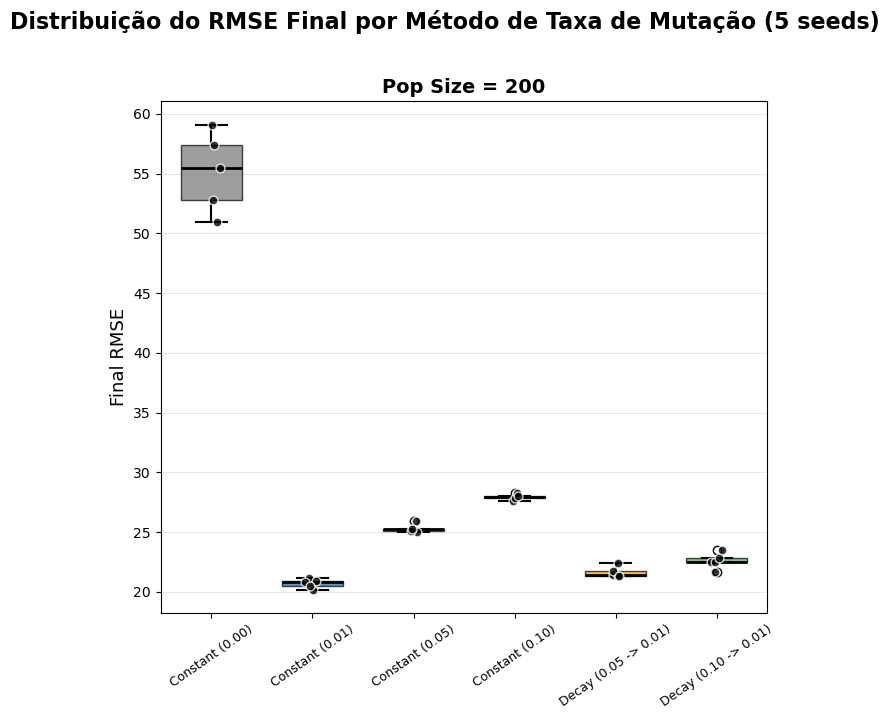

Gráfico guardado: boxplot_statistical.png


In [17]:
# =============================================================================
# BOXPLOTS — Distribuição do RMSE Final por método (5 seeds), por pop size
# =============================================================================
fig, axes = plt.subplots(1, len(POPULATION_SIZES), figsize=(7 * len(POPULATION_SIZES), 7),
                         sharey=True)
if len(POPULATION_SIZES) == 1:
    axes = [axes]

for ax_idx, pop_size in enumerate(POPULATION_SIZES):
    ax = axes[ax_idx]
    labels = []
    data = []
    colors = []

    for config_name, config in MUTATION_CONFIGS.items():
        labels.append(config['label'])
        data.append(method_rmses[(config_name, pop_size)])
        colors.append(config['color'])

    bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.6,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Sobrepor pontos individuais
    for i, (d, color) in enumerate(zip(data, colors)):
        x_jitter = np.random.normal(i + 1, 0.04, len(d))
        ax.scatter(x_jitter, d, color='black', s=40, zorder=5, alpha=0.8, edgecolors='white')

    ax.set_title(f"Pop Size = {pop_size}", fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=35, labelsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    if ax_idx == 0:
        ax.set_ylabel("Final RMSE", fontsize=13)

plt.suptitle(f"Distribuição do RMSE Final por Método de Taxa de Mutação ({len(SEEDS)} seeds)",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("boxplot_statistical.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado: boxplot_statistical.png")


### 8.3 Testes de Hipóteses — Comparação entre Métodos

**Teste 1 — Kruskal-Wallis H-test (teste omnibus):**
- H₀: Todos os métodos produzem distribuições de RMSE iguais (não há diferença)
- H₁: Pelo menos um método produz uma distribuição significativamente diferente
- Se p-value < 0.05 → rejeitamos H₀ → existe diferença significativa entre os métodos

**Teste 2 — Mann-Whitney U (testes pairwise):**
- Para cada par de métodos, testa se as suas distribuições de RMSE são significativamente diferentes
- Aplicamos **correção de Bonferroni** para múltiplas comparações: α_corrigido = 0.05 / nº_comparações

Realizamos estes testes **separadamente para cada tamanho de população**.


In [18]:
# =============================================================================
# TESTES DE HIPÓTESES — POR TAMANHO DE POPULAÇÃO
# =============================================================================
all_pairwise_results = {}  # {pop_size: {(m1,m2): {'u_stat', 'p_value'}}}

for pop_size in POPULATION_SIZES:
    print(f"\n{'#' * 65}")
    print(f"  POP SIZE = {pop_size}")
    print(f"{'#' * 65}")

    # Kruskal-Wallis
    groups = [method_rmses[(m, pop_size)] for m in method_names]
    h_stat, p_kruskal = stats.kruskal(*groups)

    print(f"\n  KRUSKAL-WALLIS (Omnibus)")
    print(f"  H-statistic: {h_stat:.4f}")
    print(f"  p-value:     {p_kruskal:.6f}")
    print(f"  Significativo (α=0.05)? {'Yes' if p_kruskal < 0.05 else 'No'}")
    if p_kruskal < 0.05:
        print("  → Rejeitamos H₀: existe diferença significativa entre métodos.")
    else:
        print("  → Não rejeitamos H₀: sem evidência de diferença significativa.")

    # Mann-Whitney U pairwise
    n_comparisons = len(list(combinations(method_names, 2)))
    alpha_bonferroni = 0.05 / n_comparisons

    print(f"\n  MANN-WHITNEY U (Pairwise)")
    print(f"  Correção de Bonferroni: α = 0.05 / {n_comparisons} = {alpha_bonferroni:.4f}")
    print(f"\n  {'Método A':<22} {'Método B':<22} {'U-stat':>7} {'p-value':>10} {'Sig?':>5}")
    print("  " + "-" * 70)

    pairwise = {}
    for m1, m2 in combinations(method_names, 2):
        u_stat, p_val = stats.mannwhitneyu(
            method_rmses[(m1, pop_size)],
            method_rmses[(m2, pop_size)],
            alternative='two-sided'
        )
        sig = "Yes" if p_val < alpha_bonferroni else "No"
        pairwise[(m1, m2)] = {'u_stat': u_stat, 'p_value': p_val}
        print(f"  {method_labels_map[m1]:<22} {method_labels_map[m2]:<22} "
              f"{u_stat:>7.1f} {p_val:>10.6f} {sig:>5}")

    all_pairwise_results[pop_size] = pairwise

    sig_pairs = [(m1, m2) for (m1, m2), r in pairwise.items()
                 if r['p_value'] < alpha_bonferroni]
    print(f"\n  Pares significativos: {len(sig_pairs)}/{n_comparisons}")
    for m1, m2 in sig_pairs:
        mean1 = np.mean(method_rmses[(m1, pop_size)])
        mean2 = np.mean(method_rmses[(m2, pop_size)])
        better = method_labels_map[m1] if mean1 < mean2 else method_labels_map[m2]
        print(f"    • {method_labels_map[m1]} vs {method_labels_map[m2]} → Melhor: {better}")



#################################################################
  POP SIZE = 200
#################################################################

  KRUSKAL-WALLIS (Omnibus)
  H-statistic: 27.9884
  p-value:     0.000037
  Significativo (α=0.05)? Yes
  → Rejeitamos H₀: existe diferença significativa entre métodos.

  MANN-WHITNEY U (Pairwise)
  Correção de Bonferroni: α = 0.05 / 15 = 0.0033

  Método A               Método B                U-stat    p-value  Sig?
  ----------------------------------------------------------------------
  Constant (0.00)        Constant (0.01)           25.0   0.007937    No
  Constant (0.00)        Constant (0.05)           25.0   0.007937    No
  Constant (0.00)        Constant (0.10)           25.0   0.007937    No
  Constant (0.00)        Decay (0.05 -> 0.01)      25.0   0.007937    No
  Constant (0.00)        Decay (0.10 -> 0.01)      25.0   0.007937    No
  Constant (0.01)        Constant (0.05)            0.0   0.007937    No
  Constant (0.01)

### 8.4 Heatmaps de P-values
Visualização matricial dos p-values de todos os pares de métodos, por tamanho de população.
Vermelho = diferença significativa (p ≈ 0). Verde = sem diferença (p ≈ 1).
O asterisco (*) indica significância após correção de Bonferroni.


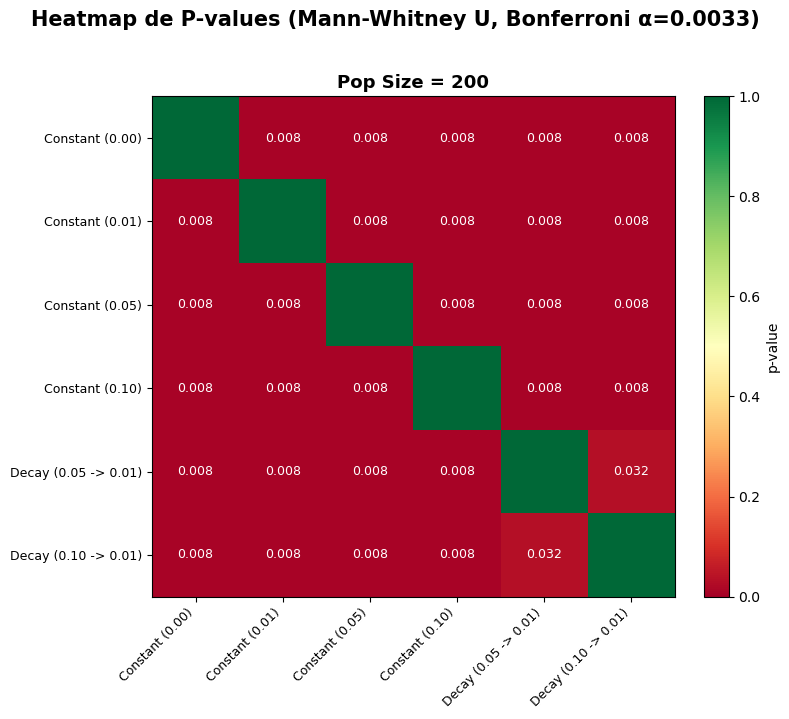

Gráfico guardado: pvalue_heatmap.png


In [19]:
# =============================================================================
# HEATMAPS DE P-VALUES — por tamanho de população
# =============================================================================
n = len(method_names)
n_comparisons = len(list(combinations(method_names, 2)))
alpha_bonferroni = 0.05 / n_comparisons

fig, axes = plt.subplots(1, len(POPULATION_SIZES), figsize=(8 * len(POPULATION_SIZES), 7))
if len(POPULATION_SIZES) == 1:
    axes = [axes]

for ax_idx, pop_size in enumerate(POPULATION_SIZES):
    ax = axes[ax_idx]
    pval_matrix = np.ones((n, n))

    pairwise = all_pairwise_results[pop_size]
    for i, m1 in enumerate(method_names):
        for j, m2 in enumerate(method_names):
            if i == j:
                pval_matrix[i, j] = 1.0
            elif (m1, m2) in pairwise:
                pval_matrix[i, j] = pairwise[(m1, m2)]['p_value']
                pval_matrix[j, i] = pairwise[(m1, m2)]['p_value']

    display_labels = [MUTATION_CONFIGS[m]['label'] for m in method_names]
    im = ax.imshow(pval_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

    ax.set_xticks(range(n))
    ax.set_xticklabels(display_labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(n))
    ax.set_yticklabels(display_labels, fontsize=9)

    for i in range(n):
        for j in range(n):
            if i != j:
                p = pval_matrix[i, j]
                sig_marker = "*" if p < alpha_bonferroni else ""
                ax.text(j, i, f"{p:.3f}{sig_marker}", ha='center', va='center',
                        fontsize=9, fontweight='bold' if sig_marker else 'normal',
                        color='white' if p < 0.3 else 'black')

    ax.set_title(f"Pop Size = {pop_size}", fontsize=13, fontweight='bold')
    plt.colorbar(im, ax=ax, label='p-value', fraction=0.046)

plt.suptitle(f"Heatmap de P-values (Mann-Whitney U, Bonferroni α={alpha_bonferroni:.4f})",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("pvalue_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado: pvalue_heatmap.png")


### 8.5 Tabela Resumo Estatístico Final
Tabela final com média, desvio-padrão, mediana, melhor/pior resultado e ranking.
Baseada em pop_size=200 (a melhor população identificada na Fase 1).


In [20]:
# =============================================================================
# TABELA RESUMO ESTATÍSTICO FINAL (Pop=200)
# =============================================================================
ref_pop = 200
print(f"{'Método':<25} {'Média':>8} {'± Std':>8} {'Mediana':>9} "
      f"{'Min':>8} {'Max':>8} {'Rank':>6}")
print("=" * 75)

# Calcular rankings por média
means = {m: np.mean(method_rmses[(m, ref_pop)]) for m in method_names}
ranked = sorted(means.items(), key=lambda x: x[1])
rank_map = {m: i + 1 for i, (m, _) in enumerate(ranked)}

for config_name, config in MUTATION_CONFIGS.items():
    vals = method_rmses[(config_name, ref_pop)]
    medal = {1: "🥇", 2: "🥈", 3: "🥉"}.get(rank_map[config_name], "  ")
    print(f"{config['label']:<25} {np.mean(vals):>8.2f} {np.std(vals):>8.2f} "
          f"{np.median(vals):>9.2f} {np.min(vals):>8.2f} {np.max(vals):>8.2f} "
          f"{medal}{rank_map[config_name]:>3d}")

print("\n" + "=" * 75)
winner = ranked[0]
print(f"\n🏆 Melhor método (por média): {MUTATION_CONFIGS[winner[0]]['label']} "
      f"(RMSE médio = {winner[1]:.2f})")
print(f"\nEste é o método de seleção recomendado para a versão final do GA.")


Método                       Média    ± Std   Mediana      Min      Max   Rank
Constant (0.00)              55.13     2.96     55.46    50.98    59.10     6
Constant (0.01)              20.72     0.35     20.83    20.19    21.18 🥇  1
Constant (0.05)              25.31     0.32     25.22    25.03    25.92     4
Constant (0.10)              27.92     0.20     27.91    27.62    28.25     5
Decay (0.05 -> 0.01)         21.64     0.43     21.40    21.31    22.43 🥈  2
Decay (0.10 -> 0.01)         22.60     0.61     22.50    21.66    23.53 🥉  3


🏆 Melhor método (por média): Constant (0.01) (RMSE médio = 20.72)

Este é o método de seleção recomendado para a versão final do GA.


## 6. Conclusões e Discussão Final

Após correr todas as experiências, responde a estas perguntas no teu relatório:

1. **Qual foi a diferença entre as taxas fixas (0.01 vs 0.10)?** 
   A agressividade destruiu boas soluções, ou o excesso de suavidade impediu a fuga de mínimos locais?
2. **O Mutation Decay ajudou?** 
   Conseguiu o melhor dos dois mundos (exploração agressiva no início, otimização fina no final)? Os p-values comprovam que é estatisticamente melhor que as taxas fixas?
3. **Qual a configuração recomendarias para a Mutação do Super GA do grupo?** (Estratégia + Taxa + Decay)
